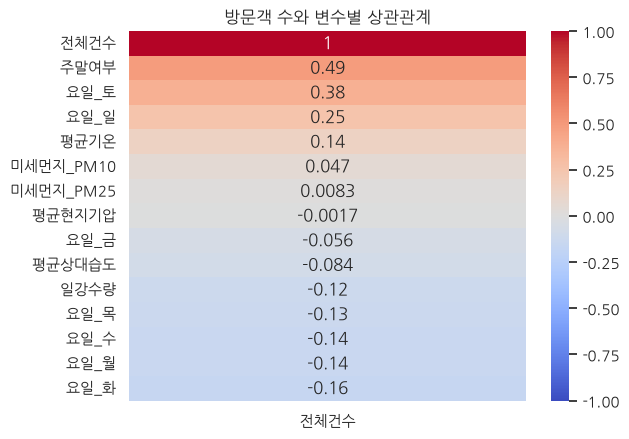

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rc('font', family='NanumGothic') # korean for plt
plt.rc('axes', unicode_minus=False) # prevent minus error
sns.set_theme(font='NanumGothic') # korean for sns

def preprocess(path):
    df = pd.read_csv(path)
    df['일자'] = pd.to_datetime(df['일자'])
    df['요일'] = df['일자'].dt.day_name().map({'Monday':'월','Tuesday':'화','Wednesday':'수','Thursday':'목','Friday':'금','Saturday':'토','Sunday':'일'})
    df['주말여부'] = (df['일자'].dt.weekday >= 5).astype(int)
    df = pd.get_dummies(df, columns=['요일'], prefix='요일', dtype=int)
    cols = ['전체건수','평균기온','일강수량','평균상대습도','평균현지기압','미세먼지_PM10','미세먼지_PM25']
    df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')
    return df[['일자','전체건수','주말여부','평균기온','일강수량','평균상대습도','평균현지기압','미세먼지_PM10','미세먼지_PM25'] + [f'요일_{d}' for d in '월화수목금토일']]

def visualize(df):
    corr = df.drop(columns='일자').corr()[['전체건수']].sort_values('전체건수', ascending=False)
    sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title('방문객 수와 변수별 상관관계')
    plt.show()

if __name__ == '__main__':
    df = preprocess('Oworld.csv')
    visualize(df)

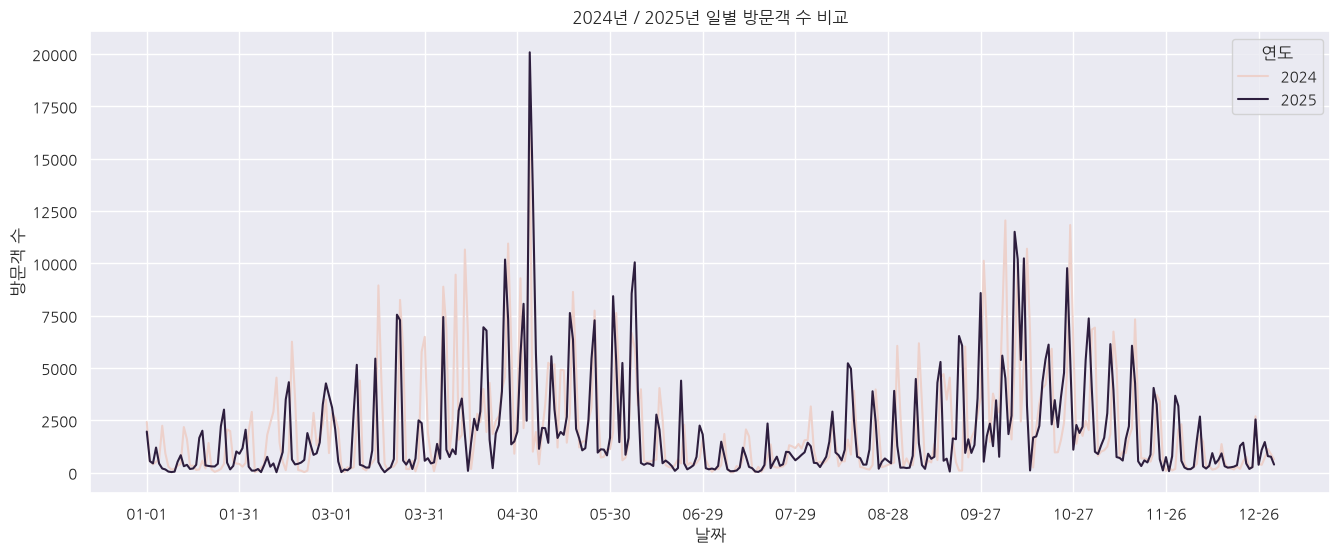

In [ ]:
df['일자'] = pd.to_datetime(df['일자'])
df['연도'] = df['일자'].dt.year
df['월일'] = df['일자'].dt.strftime('%m-%d')

temp = df[df['연도'].isin([2024, 2025])]

plt.figure(figsize=(16, 6))
sns.lineplot(data=temp, x='월일', y='전체건수', hue='연도')
plt.xticks(range(0, 365, 30))
plt.xlabel('날짜')
plt.ylabel('방문객 수')
plt.title('2024년 / 2025년 일별 방문객 수 비교')
plt.show()

대전 인근 문화행사 가져오기

In [4]:
import requests
import pandas as pd
from bs4 import BeautifulSoup

url = 'https://apis.data.go.kr/B554695/CultureScheduleSVC/getCultureSchedule01'

# 사용기간 8/12 하루임
params = {
    'ServiceKey': '2O6qkZfedoF9zCkn3ccvnpsAu4qUsrXxRG8Cws3TjjPBHBLLKrkx17xR+LTQe2DKX5aB4w1nxbyEuwIewFrcOg==',
    'pageNo': '1',
    'numOfRows': '1000',
    '_type': 'json',
    'sdate': 20230101,
    'edate': 20260812,
}

response = requests.get(url, params=params)

if response.status_code == 200:
        data = response.json()
        body = data.get('response', {}).get('body', {})
        total_count = body.get('totalCount', 0)
        print(f"=== 조회된 데이터 수: {total_count}건) ===")

        items_data = body.get('items', {}).get('item', [])
        
        # 데이터가 1건일 경우
        if isinstance(items_data, dict):
            items_data = [items_data]
            
        parsed_items = []
        for item in items_data:
            content = item.get('content', item.get('content', '-'))
            sdate = item.get('sdate', item.get('SDate', '-'))
            edate = item.get('edate', item.get('EDate', '-'))
            place = item.get('place', '-')
            
            print(f"행사명: {content} | 기간: {sdate} ~ {edate} | 장소: {place}")
            
            parsed_items.append({
                'content': content,
                'sdate': sdate,
                'edate': edate,
                'place': place
            })
        
        if parsed_items:
            df = pd.DataFrame(parsed_items)
            df.to_csv('local_events.csv', index=False, encoding='utf-8-sig')
            print("\n'local_events.csv' stored!")

=== 조회된 데이터 수: 481건) ===
행사명: 충남대평생교육원 임학빈 사진교실 | 기간: 2023-01-06 ~ 2023-01-09 | 장소: 116
행사명: 대전도시철도와 함께하는 중구 문화공연 안내 | 기간: 2023-01-06 ~ 2023-02-26 | 장소: 105
행사명: 제8회 연안관리 홍보 콘텐츠 수상작 전시 | 기간: 2023-01-09 ~ 2023-01-18 | 장소: 111
행사명: 장애아동 교육권 보장 캠페인 및 작품전시회 | 기간: 2023-01-30 ~ 2023-02-03 | 장소: 111
행사명: 시니어 패션쇼 | 기간: 2023-02-06 ~ 2023-02-06 | 장소: 111
행사명: 임동환wave의 모락모락버스킹 | 기간: 2023-02-25 ~ 2023-02-25 | 장소: 116
행사명: 중구 연극 공연 안내 | 기간: 2023-02-27 ~ 2023-03-12 | 장소: 105
행사명: 학교폭력 예방 포스터 전시 | 기간: 2023-03-02 ~ 2023-03-31 | 장소: 111
행사명: 금강사랑 그림그리기대회 수상작 전시회 | 기간: 2023-03-06 ~ 2023-03-17 | 장소: 116
행사명: 대전도시철도와 함께하는 중구 문화공연 안내 | 기간: 2023-03-14 ~ 2023-03-17 | 장소: 105
행사명: 대전도시철도와 함께하는 중구 문화공연 안내 | 기간: 2023-03-18 ~ 2023-05-07 | 장소: 105
행사명: 찾아가는 홍보 캠페인  | 기간: 2023-03-27 ~ 2023-03-31 | 장소: 101
행사명: 제3회 봄 시화전 | 기간: 2023-04-01 ~ 2023-04-15 | 장소: 104
행사명: 2023 한마음 치매극복 걷기행사 홍보부스 | 기간: 2023-04-04 ~ 2023-04-04 | 장소: 111
행사명: 캠페인 | 기간: 2023-04-12 ~ 2023-04-26 | 장소: 116
행사명: 시낭송연습 | 기간: 2023-04-16 ~ 2023-04-1

In [ ]:
import pandas as pd

def add_events():
    ow = pd.read_csv('Oworld.csv')
    ev = pd.read_csv('local_events.csv')

    ow['일자'] = pd.to_datetime(ow['일자'])
    ev['sdate'] = pd.to_datetime(ev['sdate'])
    ev['edate'] = pd.to_datetime(ev['edate'])

    ow['인근행사수'] = ow['일자'].apply(
        lambda date: ((ev['sdate'] <= date) & (ev['edate'] >= date)).sum()
    )

    ow.to_csv('Oworld_events.csv', index=False, encoding='utf-8-sig')

    print(ow[['일자', '인근행사수']].head(20))


if __name__ == '__main__':
    add_events()

           일자  인근행사수
0  2023-01-01      0
1  2023-01-02      0
2  2023-01-03      0
3  2023-01-04      0
4  2023-01-05      0
5  2023-01-06      2
6  2023-01-07      2
7  2023-01-08      2
8  2023-01-09      3
9  2023-01-10      2
10 2023-01-11      2
11 2023-01-12      2
12 2023-01-13      2
13 2023-01-14      2
14 2023-01-15      2
15 2023-01-16      2
16 2023-01-17      2
17 2023-01-18      2
18 2023-01-19      1
19 2023-01-20      1


인근행사수와 방문자수의 상관계수: -0.123
약한 음의 상관관계


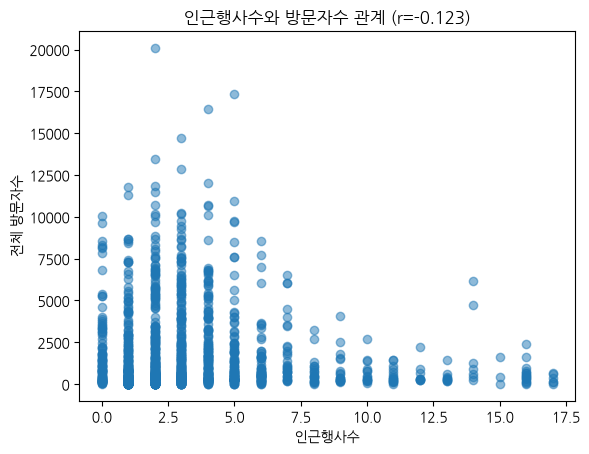

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rc('font', family='NanumGothic') # korean for plt
plt.rc('axes', unicode_minus=False) # prevent minus error

def analyze_correlation():
    df = pd.read_csv('Oworld_events.csv')

    correlation = df['인근행사수'].corr(df['전체건수'])

    print(f"인근행사수와 방문자수의 상관계수: {correlation:.3f}")

    if correlation >= 0.7:
        print("강한 양의 상관관계")
    elif correlation >= 0.3:
        print("중간 정도의 양의 상관관계")
    elif correlation > 0:
        print("약한 양의 상관관계")
    elif correlation <= -0.7:
        print("강한 음의 상관관계")
    elif correlation <= -0.3:
        print("중간 정도의 음의 상관관계")
    elif correlation < 0:
        print("약한 음의 상관관계")
    else:
        print("상관관계 없음")

    plt.scatter(df['인근행사수'], df['전체건수'], alpha=0.5)
    plt.xlabel('인근행사수')
    plt.ylabel('전체 방문자수')
    plt.title(f'인근행사수와 방문자수 관계 (r={correlation:.3f})')
    plt.show()


if __name__ == '__main__':
    analyze_correlation()

In [5]:
import pandas as pd

def merge_event_features():
    df = pd.read_csv('Oworld_wy.csv')
    ev = pd.read_csv('Oworld_events.csv', usecols=['일자', '인근행사수'])

    df['행사구분'] = df['행사구분'].map({
        '행사 없음': 0,
        '행사 있음': 1
    })

    df['일자'] = pd.to_datetime(df['일자'])
    ev['일자'] = pd.to_datetime(ev['일자'])

    df = df.merge(ev, on='일자', how='left')

    df['인근행사수'] = df['인근행사수'].fillna(0).astype(int)

    df.to_csv('Oworld_wy.csv', index=False, encoding='utf-8-sig')

    print(df[['일자', '행사구분', '인근행사수']].head(20))


if __name__ == '__main__':
    merge_event_features()

           일자  행사구분  인근행사수
0  2023-01-01     0      0
1  2023-01-02     0      0
2  2023-01-03     0      0
3  2023-01-04     0      0
4  2023-01-05     0      0
5  2023-01-06     0      2
6  2023-01-07     0      2
7  2023-01-08     0      2
8  2023-01-09     0      3
9  2023-01-10     0      2
10 2023-01-11     0      2
11 2023-01-12     0      2
12 2023-01-13     0      2
13 2023-01-14     0      2
14 2023-01-15     0      2
15 2023-01-16     0      2
16 2023-01-17     0      2
17 2023-01-18     0      2
18 2023-01-19     0      1
19 2023-01-20     0      1


사용할 Feature 추출

In [23]:
import pandas as pd


def create_oworld_files():
    df = pd.read_csv('Oworld_wy.csv')

    # Oworld.csv
    oworld = pd.DataFrame({
        'date': df['일자'], # 식별용

        'holiday': df['is_holiday'], # 데이터 신뢰도 검증 필요
        'weekend': df['주말여부'],

        'mon': df['요일_0'],
        'tue': df['요일_1'],
        'wed': df['요일_2'],
        'thur': df['요일_3'],
        'fri': df['요일_4'],
        'sat': df['요일_5'],
        'sun': df['요일_6'],

        'temperature': df['평균기온'],
        'rain': df['일강수량'],
        'humidity': df['평균상대습도'],
        'visitors': df['전체건수'], # target

    })

    # Oworld_hold.csv
    oworld_hold = pd.DataFrame({
        'date': df['일자'], # 식별용

        'dayoff': ((df['주말여부'] == 1) | (df['is_holiday'] == 1)).astype(int),

        # 아직 데이터 없음
        'sandwich': None,

        'jan': (df['월'] == 1).astype(int),
        'feb': (df['월'] == 2).astype(int),
        'mar': (df['월'] == 3).astype(int),
        'apr': (df['월'] == 4).astype(int),
        'may': (df['월'] == 5).astype(int),
        'jun': (df['월'] == 6).astype(int),
        'jul': (df['월'] == 7).astype(int),
        'aug': (df['월'] == 8).astype(int),
        'sep': (df['월'] == 9).astype(int),
        'oct': (df['월'] == 10).astype(int),
        'nov': (df['월'] == 11).astype(int),
        'dec': (df['월'] == 12).astype(int),

        'spring': df['계절_봄'],
        'summer': df['계절_여름'],
        'fall': df['계절_가을'],
        'winter': df['계절_겨울'],

        # 아직 데이터 없음
        'event': None
    })

    oworld.to_csv('Oworld_rain.csv', index=False, encoding='utf-8-sig')
    oworld_hold.to_csv('Oworld_hold.csv', index=False, encoding='utf-8-sig')


if __name__ == '__main__':
    create_oworld_files()

강수량 -> 강수확률로 변경

In [43]:
import pandas as pd

threshold = 1.0 # 1mm 이상

df = pd.read_csv('Oworld_rain.csv')
df['rain'] = (df['rain'] >= threshold).astype(float)
df.to_csv('Oworld_missing.csv', index=False, encoding='utf-8-sig')
print(f'처리 후 데이터 수: {len(df)}건')

처리 후 데이터 수: 1277건


결측치 확인

In [44]:
import pandas as pd
import datetime as dt

df.to_csv('Oworld_missing.csv', index=False, encoding='utf-8-sig')

# check_weather
columns = ['temperature', 'humidity']
for col in columns:
    count = (df[col] == 0).sum()
    print(f'{col}: {count}건')

# check_visitors
missing_dates = df.loc[df['visitors'] == 0, 'date'].tolist()
print(f'visitors 제거: {len(missing_dates)}건')
print(missing_dates)
df = df[df['visitors'] != 0]

df['date'] = pd.to_datetime(df['date'])
children = df.loc[((df['date'].dt.month == 5) & (df['date'].dt.day == 5)), 'date'].tolist()
print(f'어린이날 제거: {len(children)}건')
print(children)
df = df[~((df['date'].dt.month == 5) & (df['date'].dt.day == 5))]

df.to_csv('Oworld.csv', index=False, encoding='utf-8-sig')
print(f'처리 후 데이터 수: {len(df)}건')

temperature: 0건
humidity: 0건
visitors 제거: 57건
['2026-04-08', '2026-04-09', '2026-04-10', '2026-04-11', '2026-04-12', '2026-04-13', '2026-04-14', '2026-04-15', '2026-04-16', '2026-04-17', '2026-04-18', '2026-04-19', '2026-04-20', '2026-04-21', '2026-04-22', '2026-04-23', '2026-04-24', '2026-04-25', '2026-04-26', '2026-04-27', '2026-04-28', '2026-04-29', '2026-04-30', '2026-05-01', '2026-05-02', '2026-05-03', '2026-05-04', '2026-05-05', '2026-05-06', '2026-05-07', '2026-05-08', '2026-05-09', '2026-05-10', '2026-05-11', '2026-05-12', '2026-05-13', '2026-05-14', '2026-05-15', '2026-05-16', '2026-05-17', '2026-05-18', '2026-05-19', '2026-05-20', '2026-05-21', '2026-05-22', '2026-05-23', '2026-05-24', '2026-05-25', '2026-05-26', '2026-05-27', '2026-05-28', '2026-05-29', '2026-05-30', '2026-05-31', '2026-06-01', '2026-06-02', '2026-06-03']
어린이날 제거: 3건
[Timestamp('2023-05-05 00:00:00'), Timestamp('2024-05-05 00:00:00'), Timestamp('2025-05-05 00:00:00')]
처리 후 데이터 수: 1217건


In [ ]:
# holiday가 주말+공휴일로 되어있어 변경

df = pd.read_csv('Oworld.csv')
source = pd.read_csv('Oworld_final_processed.csv')

df['holiday'] = source['holiday']

df.to_csv('Oworld.csv', index=False, encoding='utf-8-sig')

0    1
1    0
2    0
3    0
4    0
Name: holiday, dtype: int64


In [56]:
# 공휴일 데이터 신뢰도 확인

df = pd.read_csv('Oworld.csv')

holidays = df[df['holiday'] == 1]

print(f'holiday == 1: {len(holidays)}건')
print(holidays['date'].tolist())

holiday == 1: 62건
['2023-01-01', '2023-01-21', '2023-01-22', '2023-01-23', '2023-01-24', '2023-03-01', '2023-05-01', '2023-05-27', '2023-05-29', '2023-06-06', '2023-08-15', '2023-09-28', '2023-09-29', '2023-09-30', '2023-10-02', '2023-10-03', '2023-10-09', '2023-12-25', '2024-01-01', '2024-02-09', '2024-02-10', '2024-02-11', '2024-02-12', '2024-03-01', '2024-04-10', '2024-05-01', '2024-05-06', '2024-05-15', '2024-06-06', '2024-08-15', '2024-09-16', '2024-09-17', '2024-09-18', '2024-10-01', '2024-10-03', '2024-10-09', '2024-12-25', '2025-01-01', '2025-01-27', '2025-01-28', '2025-01-29', '2025-01-30', '2025-03-01', '2025-03-03', '2025-05-01', '2025-05-06', '2025-06-03', '2025-06-06', '2025-08-15', '2025-10-03', '2025-10-05', '2025-10-06', '2025-10-07', '2025-10-08', '2025-10-09', '2025-12-25', '2026-01-01', '2026-02-16', '2026-02-17', '2026-02-18', '2026-03-01', '2026-03-02']


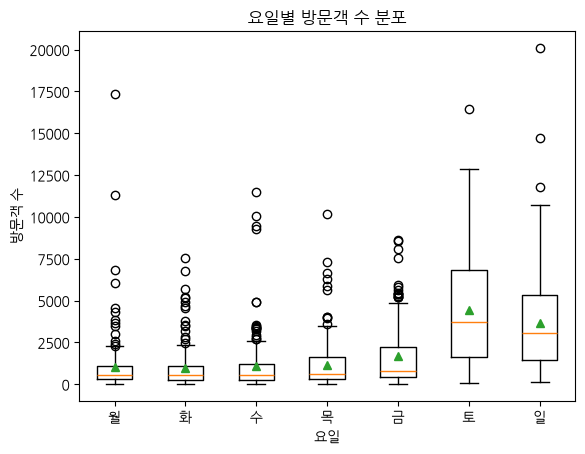

         count         mean  median  min    max
weekday                                        
mon        174  1025.827586   543.5   14  17317
tue        175   970.160000   519.0   13   7563
wed        173  1105.086705   538.0   18  11506
thur       174  1169.959770   584.0    1  10194
fri        173  1657.930636   811.0    4   8644
sat        174  4448.321839  3701.0   42  16458
sun        174  3652.149425  3056.5  125  20083


In [54]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('Oworld.csv')

days = ['mon', 'tue', 'wed', 'thur', 'fri', 'sat', 'sun']
labels = ['월', '화', '수', '목', '금', '토', '일']

data = [df.loc[df[day] == 1, 'visitors'] for day in days]

plt.boxplot(data, tick_labels=labels, showmeans=True)
plt.xlabel('요일')
plt.ylabel('방문객 수')
plt.title('요일별 방문객 수 분포')
plt.show()

print(df.assign(
    weekday=df[days].idxmax(axis=1)
).groupby('weekday')['visitors'].agg(['count', 'mean', 'median', 'min', 'max']).reindex(days))

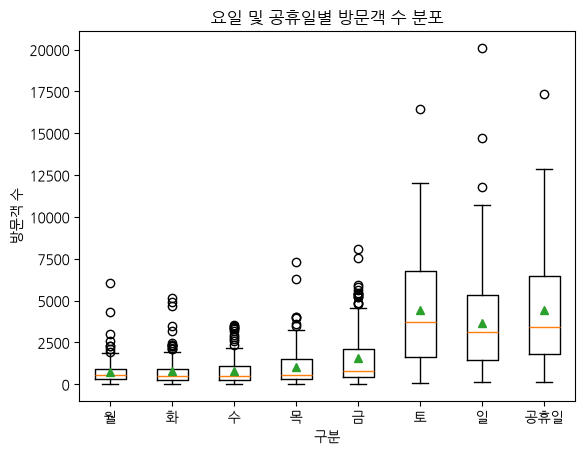

월: 평균=739, 중앙값=520, 최대=6034, 데이터수=159
화: 평균=773, 중앙값=505, 최대=5177, 데이터수=164
수: 평균=810, 중앙값=498, 최대=3536, 데이터수=162
목: 평균=1009, 중앙값=540, 최대=7327, 데이터수=165
금: 평균=1551, 중앙값=777, 최대=8065, 데이터수=167
토: 평균=4417, 중앙값=3711, 최대=16458, 데이터수=169
일: 평균=3651, 중앙값=3104, 최대=20083, 데이터수=169
공휴일: 평균=4433, 중앙값=3407, 최대=17317, 데이터수=62


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('Oworld.csv')

groups = [
    df.loc[(df['holiday'] == 0) & (df['mon'] == 1), 'visitors'],
    df.loc[(df['holiday'] == 0) & (df['tue'] == 1), 'visitors'],
    df.loc[(df['holiday'] == 0) & (df['wed'] == 1), 'visitors'],
    df.loc[(df['holiday'] == 0) & (df['thur'] == 1), 'visitors'],
    df.loc[(df['holiday'] == 0) & (df['fri'] == 1), 'visitors'],
    df.loc[(df['holiday'] == 0) & (df['sat'] == 1), 'visitors'],
    df.loc[(df['holiday'] == 0) & (df['sun'] == 1), 'visitors'],
    df.loc[df['holiday'] == 1, 'visitors']
]

labels = ['월', '화', '수', '목', '금', '토', '일', '공휴일']

plt.boxplot(groups, tick_labels=labels, showmeans=True)
plt.xlabel('구분')
plt.ylabel('방문객 수')
plt.title('
요일 및 공휴일별 방문객 수 분포')
plt.show()

for label, data in zip(labels, groups):
    print(f'{label}: 평균={data.mean():.0f}, 중앙값={data.median():.0f}, 최대={data.max():.0f}, 데이터수={len(data)}')

In [60]:
# dayoff, nextdayoff(다음날이 쉬는날) 컬럼 생성 -> Oworld_temp.csv
# 다음 날짜가 데이터에 없으면 nextdayoff=0 처리 + 수작업으로 처리

import pandas as pd

df = pd.read_csv('Oworld.csv')
df['date'] = pd.to_datetime(df['date'])

# dayoff
df['dayoff'] = ((df['holiday'] == 1) | (df['weekend'] == 1)).astype(int)

# 전날/다음날이 실제로 존재하는지 확인
prev_exists = df['date'].shift(1) == df['date'] - pd.Timedelta(days=1)
next_exists = df['date'].shift(-1) == df['date'] + pd.Timedelta(days=1)

# nextdayoff
df['nextdayoff'] = 0
df.loc[next_exists, 'nextdayoff'] = df['dayoff'].shift(-1)[next_exists].astype(int)

# sandwich: 본인은 평일 + 앞뒤 모두 dayoff
df['sandwich'] = (
    (df['dayoff'] == 0) & prev_exists & next_exists & (df['dayoff'].shift(1) == 1) & (df['dayoff'].shift(-1) == 1)
).astype(int)

# 컬럼 순서
cols = df.columns.tolist()

for col in ['dayoff', 'nextdayoff', 'sandwich']:
    cols.remove(col)

pos = cols.index('weekend') + 1
cols[pos:pos] = ['sandwich', 'dayoff', 'nextdayoff']

df = df[cols]

# 다음 날짜가 없는 행 출력
missing_next = df.loc[~next_exists, 'date']

print(f'다음 날짜가 없는 행: {len(missing_next)}건')
print(missing_next.dt.strftime('%Y-%m-%d').tolist())

# 샌드위치 일자 출력
sandwich_dates = df.loc[df['sandwich'] == 1, 'date']

print(f'\n샌드위치 일자: {len(sandwich_dates)}건')
print(sandwich_dates.dt.strftime('%Y-%m-%d').tolist())

# dayoff
df['dayoff'] = ((df['holiday'] == 1) | (df['weekend'] == 1) | (df['sandwich'] == 1)).astype(int)

df.to_csv('Oworld_temp.csv', index=False, encoding='utf-8-sig')

다음 날짜가 없는 행: 5건
['2023-05-04', '2024-05-04', '2025-05-04', '2026-04-07', '2026-06-30']

샌드위치 일자: 13건
['2023-06-05', '2023-08-14', '2024-06-07', '2024-08-16', '2024-09-30', '2024-10-02', '2024-10-04', '2025-01-31', '2025-05-02', '2025-06-02', '2025-10-10', '2025-12-26', '2026-01-02']


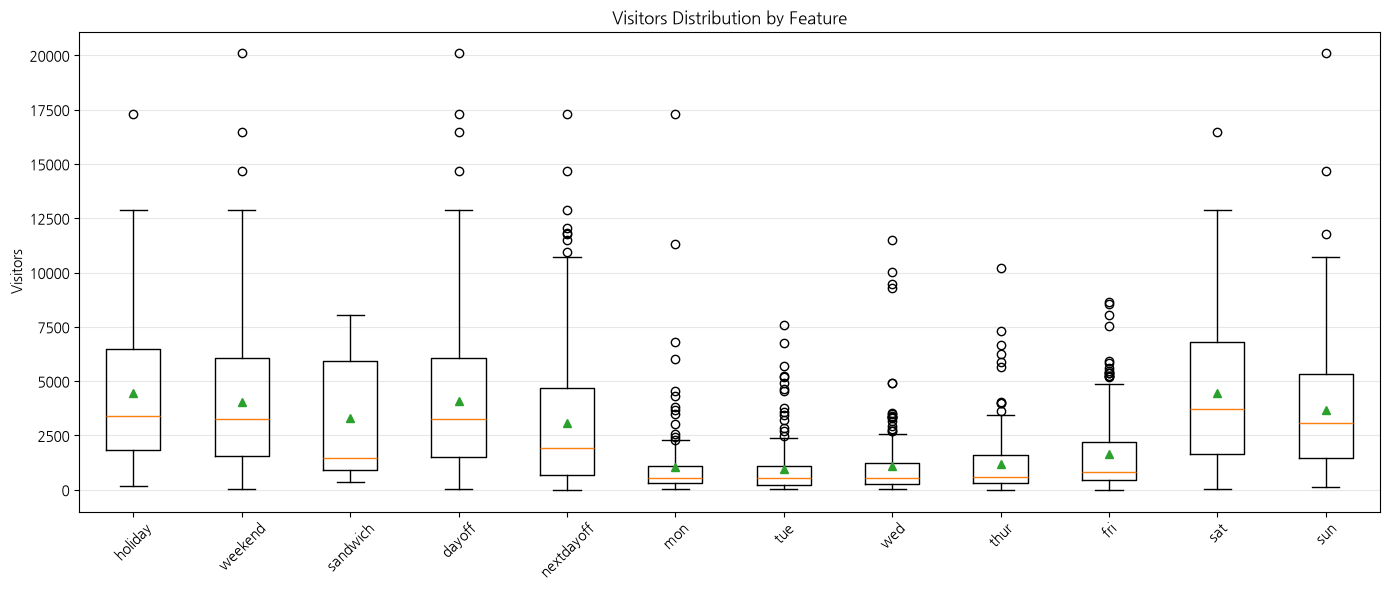

holiday      count= 62  mean= 4433.0  median= 3407.0  min=  153  max=17317
weekend      count=348  mean= 4050.2  median= 3263.0  min=   42  max=20083
sandwich     count= 13  mean= 3310.6  median= 1478.0  min=  373  max= 8065
dayoff       count=413  mean= 4071.2  median= 3265.0  min=   42  max=20083
nextdayoff   count=396  mean= 3083.5  median= 1940.0  min=    4  max=17317
mon          count=174  mean= 1025.8  median=  543.5  min=   14  max=17317
tue          count=175  mean=  970.2  median=  519.0  min=   13  max= 7563
wed          count=173  mean= 1105.1  median=  538.0  min=   18  max=11506
thur         count=174  mean= 1170.0  median=  584.0  min=    1  max=10194
fri          count=173  mean= 1657.9  median=  811.0  min=    4  max= 8644
sat          count=174  mean= 4448.3  median= 3701.0  min=   42  max=16458
sun          count=174  mean= 3652.1  median= 3056.5  min=  125  max=20083


In [61]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('Oworld_temp.csv')

features = [
    'holiday', 'weekend', 'sandwich', 'dayoff', 'nextdayoff',
    'mon', 'tue', 'wed', 'thur', 'fri', 'sat', 'sun'
]

data = [df.loc[df[col] == 1, 'visitors'] for col in features]

plt.figure(figsize=(14, 6))
plt.boxplot(data, tick_labels=features, showmeans=True)
plt.ylabel('Visitors')
plt.title('Visitors Distribution by Feature')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

for col in features:
    v = df.loc[df[col] == 1, 'visitors']

    print(
        f'{col:12} '
        f'count={len(v):3}  '
        f'mean={v.mean():7.1f}  '
        f'median={v.median():7.1f}  '
        f'min={v.min():5.0f}  '
        f'max={v.max():5.0f}'
    )

In [63]:
import pandas as pd

df = pd.read_csv('Oworld_temp.csv')

low = df[df['visitors'] <= 100]

result = dict(zip(low['date'], low['visitors']))

print(f'100 이하 행 개수: {len(low)}건')
print(result)

100 이하 행 개수: 58건
{'2023-01-25': 32, '2023-01-26': 96, '2023-06-26': 37, '2023-06-29': 47, '2023-07-04': 22, '2023-07-11': 57, '2023-07-13': 30, '2023-07-14': 4, '2023-07-15': 42, '2023-07-18': 15, '2023-08-10': 1, '2023-08-29': 92, '2023-08-30': 34, '2023-12-11': 25, '2023-12-15': 21, '2023-12-18': 100, '2023-12-19': 68, '2023-12-21': 38, '2024-01-23': 36, '2024-01-24': 92, '2024-02-05': 16, '2024-02-20': 89, '2024-02-21': 23, '2024-02-22': 93, '2024-03-05': 16, '2024-03-28': 62, '2024-04-03': 69, '2024-07-02': 38, '2024-07-08': 14, '2024-07-09': 13, '2024-07-16': 16, '2024-07-18': 30, '2024-09-20': 96, '2024-09-21': 96, '2024-11-26': 81, '2024-11-28': 100, '2025-01-08': 47, '2025-01-09': 25, '2025-01-10': 45, '2025-02-04': 93, '2025-02-05': 95, '2025-02-07': 22, '2025-02-12': 18, '2025-03-04': 24, '2025-03-18': 16, '2025-04-14': 82, '2025-06-20': 83, '2025-07-08': 63, '2025-07-09': 70, '2025-07-10': 100, '2025-07-16': 51, '2025-07-17': 31, '2025-09-17': 51, '2025-11-27': 67, '2026-01-

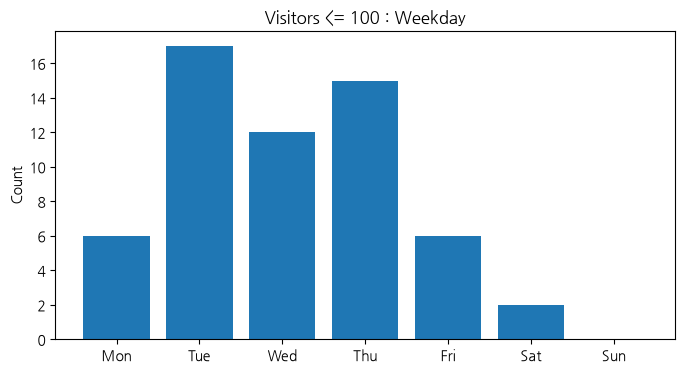

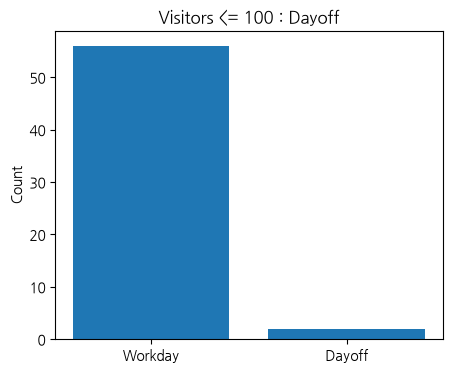

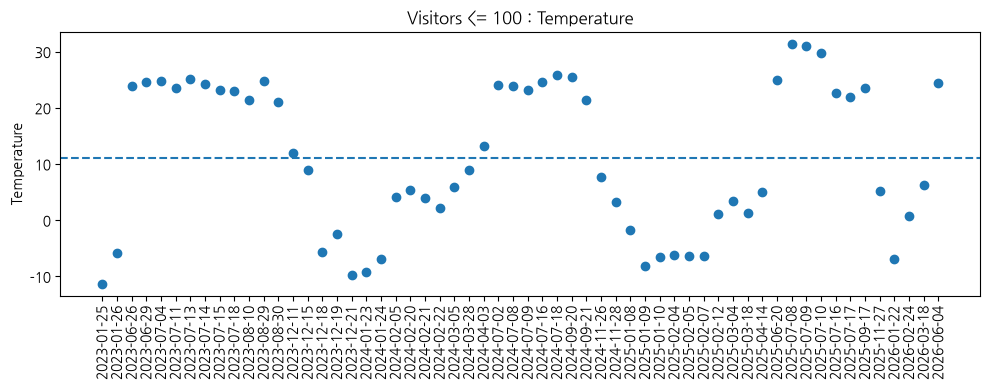

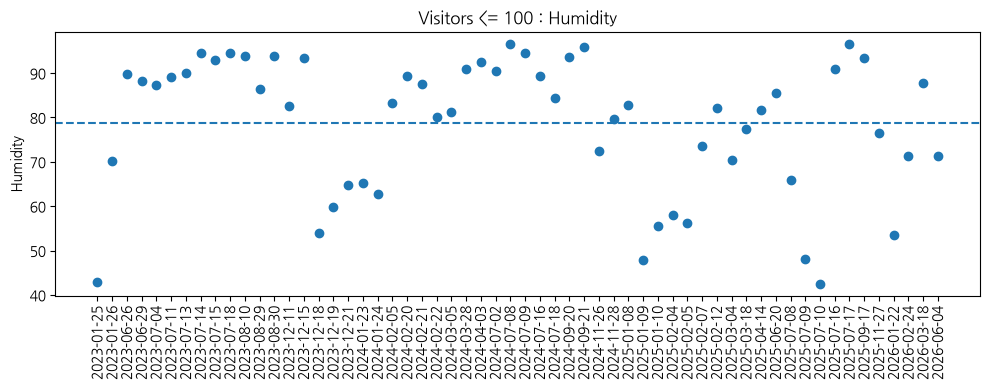

            date  visitors weekday  dayoff  temperature  humidity
24    2023-01-25        32     wed       0        -11.4      42.9
25    2023-01-26        96    thur       0         -5.8      70.1
175   2023-06-26        37     mon       0         23.8      89.8
178   2023-06-29        47    thur       0         24.6      88.1
183   2023-07-04        22     tue       0         24.7      87.3
190   2023-07-11        57     tue       0         23.6      89.0
192   2023-07-13        30    thur       0         25.2      90.0
193   2023-07-14         4     fri       0         24.2      94.5
194   2023-07-15        42     sat       1         23.2      93.0
197   2023-07-18        15     tue       0         23.0      94.4
220   2023-08-10         1    thur       0         21.3      93.8
239   2023-08-29        92     tue       0         24.8      86.3
240   2023-08-30        34     wed       0         21.1      93.9
343   2023-12-11        25     mon       0         11.9      82.6
347   2023

In [64]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('Oworld_temp.csv')
low = df[df['visitors'] <= 100].copy()

days = ['mon', 'tue', 'wed', 'thur', 'fri', 'sat', 'sun']
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

low['weekday'] = low[days].idxmax(axis=1)

# 1. 요일별 개수
weekday_count = low['weekday'].value_counts().reindex(days, fill_value=0)

plt.figure(figsize=(8, 4))
plt.bar(day_names, weekday_count)
plt.title('Visitors <= 100 : Weekday')
plt.ylabel('Count')
plt.show()

# 2. dayoff 여부
dayoff_count = low['dayoff'].value_counts().reindex([0, 1], fill_value=0)

plt.figure(figsize=(5, 4))
plt.bar(['Workday', 'Dayoff'], dayoff_count)
plt.title('Visitors <= 100 : Dayoff')
plt.ylabel('Count')
plt.show()

# 3. 기온
plt.figure(figsize=(10, 4))
plt.scatter(low['date'], low['temperature'])
plt.axhline(low['temperature'].mean(), linestyle='--')
plt.xticks(rotation=90)
plt.ylabel('Temperature')
plt.title('Visitors <= 100 : Temperature')
plt.tight_layout()
plt.show()

# 4. 습도
plt.figure(figsize=(10, 4))
plt.scatter(low['date'], low['humidity'])
plt.axhline(low['humidity'].mean(), linestyle='--')
plt.xticks(rotation=90)
plt.ylabel('Humidity')
plt.title('Visitors <= 100 : Humidity')
plt.tight_layout()
plt.show()

print(low[['date', 'visitors', 'weekday', 'dayoff', 'temperature', 'humidity']])

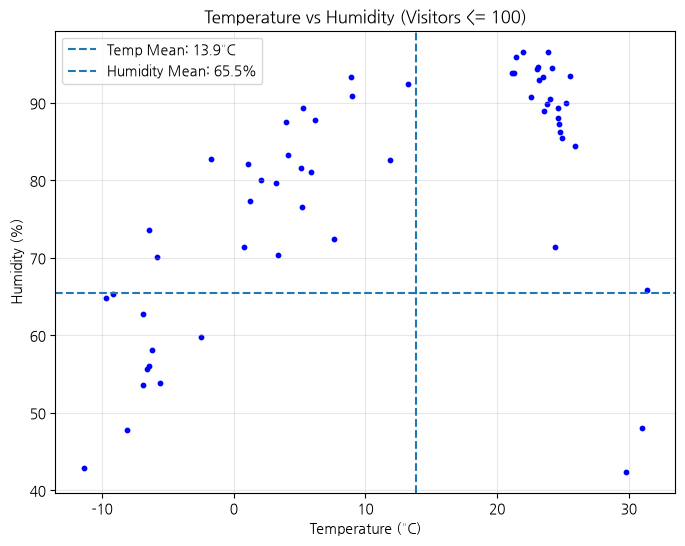

전체 평균 기온: 13.9°C
전체 평균 습도: 65.5%


In [80]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('Oworld_temp.csv')
low = df[df['visitors'] <= 100].copy()

temp_mean = df['temperature'].mean()
humidity_mean = df['humidity'].mean()

plt.figure(figsize=(8, 6))
plt.scatter(low['temperature'], low['humidity'], c='blue', s=10)

# 전체 데이터 평균
plt.axvline(temp_mean, linestyle='--', label=f'Temp Mean: {temp_mean:.1f}°C')
plt.axhline(humidity_mean, linestyle='--', label=f'Humidity Mean: {humidity_mean:.1f}%')

plt.xlabel('Temperature (°C)')
plt.ylabel('Humidity (%)')
plt.title('Temperature vs Humidity (Visitors <= 100)')
plt.grid(alpha=0.3)
plt.legend()

plt.show()

print(f'전체 평균 기온: {temp_mean:.1f}°C')
print(f'전체 평균 습도: {humidity_mean:.1f}%')

In [73]:
df.describe()

,holiday,weekend,sandwich,dayoff,nextdayoff,mon,tue,wed,thur,fri,sat,sun,temperature,rain,humidity,visitors
count,1217.000000,1217.000000,1217.000000,1217.000000,1217.000000,1217.000000,1217.000000,1217.000000,1217.000000,1217.000000,1217.000000,1217.000000,1217.000000,1217.000000,1217.000000,1217.000000
mean,0.050945,0.285949,0.010682,0.339359,0.325390,0.142975,0.143796,0.142153,0.142975,0.142153,0.142975,0.142975,13.860805,0.219392,65.522597,2004.378800
std,0.219976,0.452051,0.102843,0.473686,0.468713,0.350191,0.351027,0.349350,0.350191,0.349350,0.350191,0.350191,10.383706,0.414005,14.657736,2507.232455
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-11.400000,0.000000,24.400000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.500000,0.000000,54.800000,382.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.500000,0.000000,66.500000,928.000000
75%,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.100000,0.000000,76.000000,2573.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,31.600000,1.000000,97.400000,20083.000000


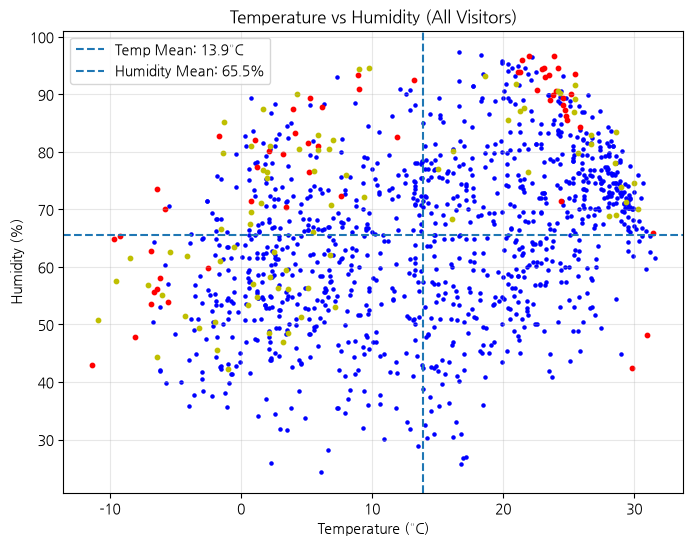

전체 평균 기온: 13.9°C
전체 평균 습도: 65.5%


In [87]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('Oworld_temp.csv')
low = df[df['visitors'] <= 100].copy()
low2 = df[(100 < df['visitors']) & (df['visitors'] <= 200)].copy()


temp_mean = df['temperature'].mean()
humidity_mean = df['humidity'].mean()

plt.figure(figsize=(8, 6))
plt.scatter(df['temperature'], df['humidity'],  c='blue', s=5)
plt.scatter(low['temperature'], low['humidity'], c='red', s=10)
plt.scatter(low2['temperature'], low2['humidity'], c='y', s=10)

# 전체 데이터 평균
plt.axvline(temp_mean, linestyle='--', label=f'Temp Mean: {temp_mean:.1f}°C')
plt.axhline(humidity_mean, linestyle='--', label=f'Humidity Mean: {humidity_mean:.1f}%')

plt.xlabel('Temperature (°C)')
plt.ylabel('Humidity (%)')
plt.title('Temperature vs Humidity (All Visitors)')
plt.grid(alpha=0.3)
plt.legend()

plt.show()

print(f'전체 평균 기온: {temp_mean:.1f}°C')
print(f'전체 평균 습도: {humidity_mean:.1f}%')

rain          -0.171740
tue           -0.169115
mon           -0.159478
wed           -0.146069
thur          -0.135988
humidity      -0.106351
fri           -0.056272
sandwich       0.054158
temperature    0.157870
holiday        0.224515
sun            0.268543
nextdayoff     0.299049
sat            0.398297
weekend        0.516582
dayoff         0.591076
Name: visitors, dtype: float64


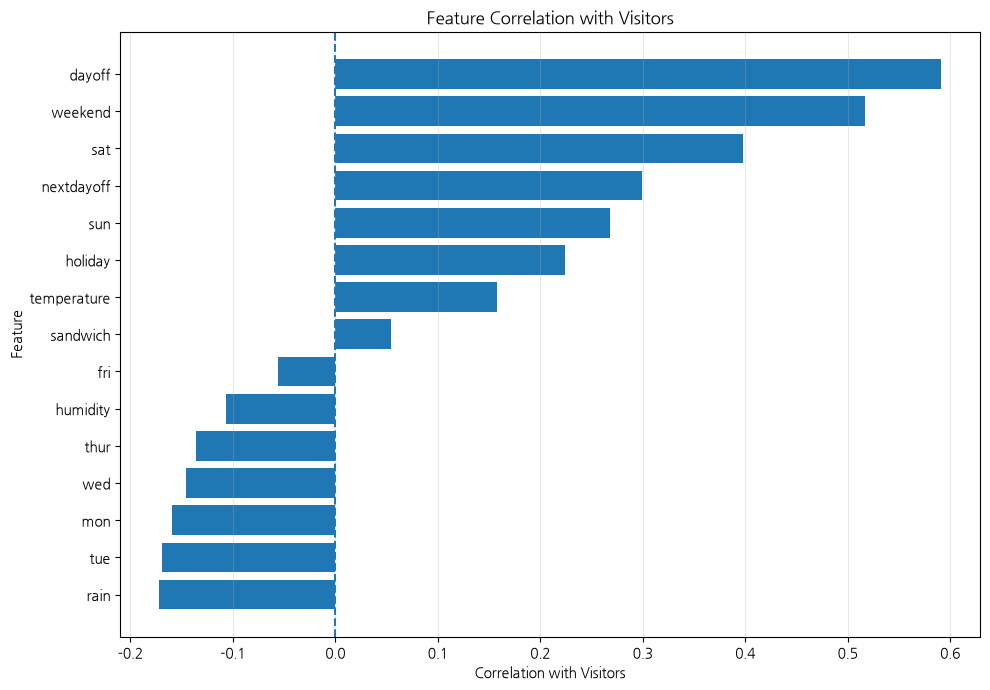

In [88]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('Oworld_temp.csv')

corr = df.corr(numeric_only=True)['visitors'].drop('visitors')
corr = corr.sort_values()

print(corr)

plt.figure(figsize=(10, 7))
plt.barh(corr.index, corr.values)

plt.axvline(0, linestyle='--')
plt.xlabel('Correlation with Visitors')
plt.ylabel('Feature')
plt.title('Feature Correlation with Visitors')
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

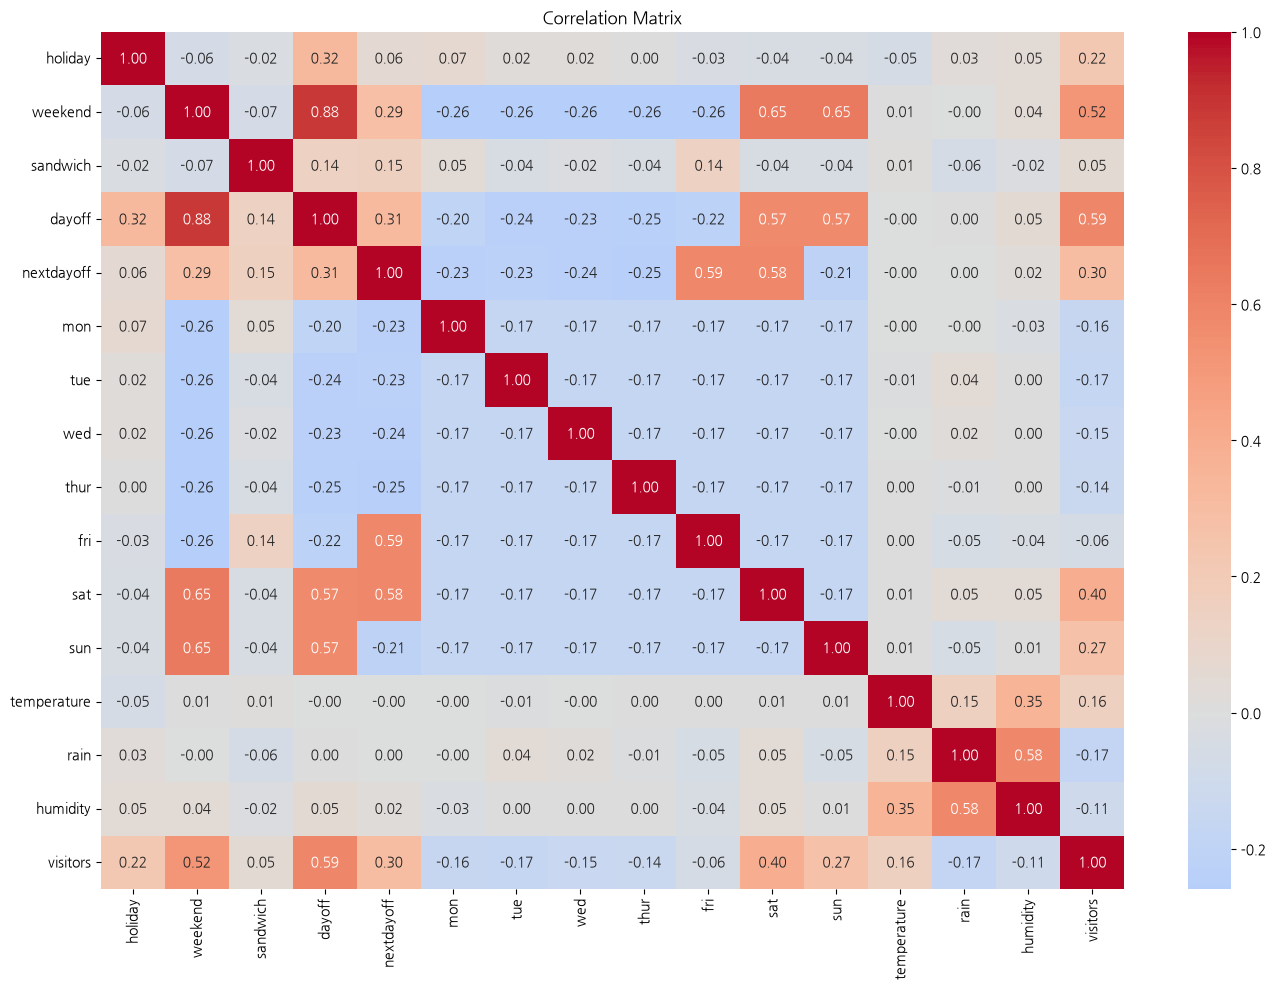

In [95]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 상관행렬
df = pd.read_csv('Oworld_temp.csv')

corr = df.corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)

plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

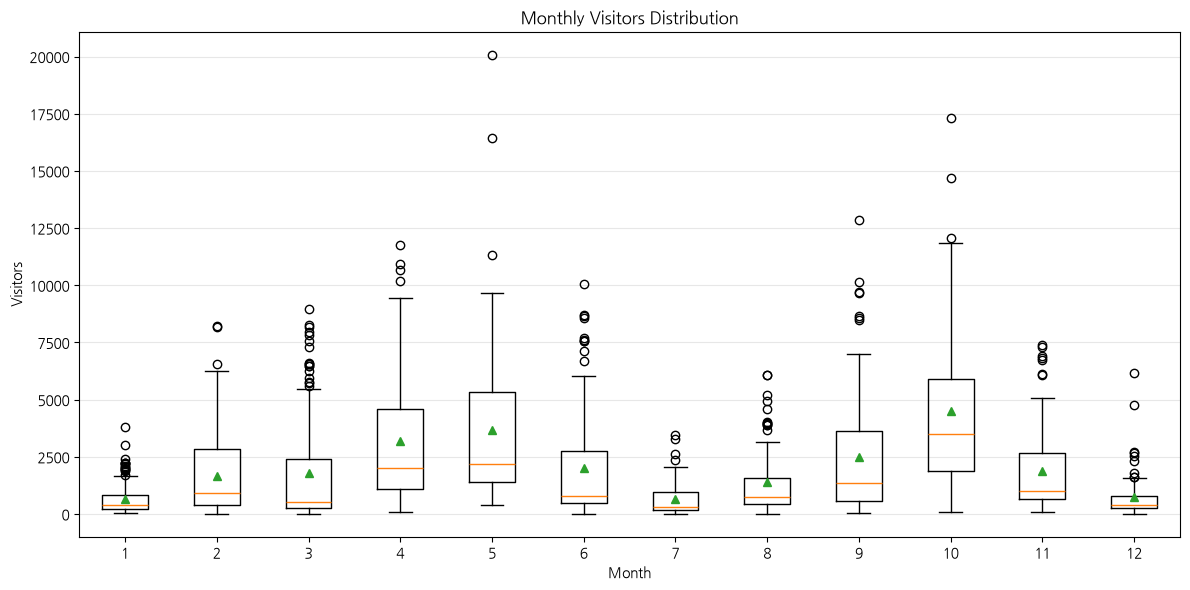

In [96]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('Oworld_temp.csv')
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month

data = [df.loc[df['month'] == m, 'visitors'] for m in range(1, 13)]

plt.figure(figsize=(12, 6))
plt.boxplot(data, tick_labels=range(1, 13), showmeans=True)

plt.xlabel('Month')
plt.ylabel('Visitors')
plt.title('Monthly Visitors Distribution')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [98]:
import pandas as pd

df = pd.read_csv('Oworld_temp.csv')
df['date'] = pd.to_datetime(df['date'])

months = ['jan', 'feb', 'mar', 'apr', 'may', 'jun',
          'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

for i, month in enumerate(months, 1):
    df[month] = (df['date'].dt.month == i).astype(int)

cols = df.columns.tolist()

for month in months:
    cols.remove(month)

pos = cols.index('sun') + 1
cols[pos:pos] = months

df = df[cols]

df.to_csv('Oworld_temp.csv', index=False, encoding='utf-8-sig')

print(df.head())

        date  holiday  weekend  sandwich  dayoff  nextdayoff  mon  tue  wed  \
0 2023-01-01        1        1         0       1           0    0    0    0   
1 2023-01-02        0        0         0       0           0    1    0    0   
2 2023-01-03        0        0         0       0           0    0    1    0   
3 2023-01-04        0        0         0       0           0    0    0    1   
4 2023-01-05        0        0         0       0           0    0    0    0   

   thur  ...  jul  aug  sep  oct  nov  dec  temperature  rain  humidity  \
0     0  ...    0    0    0    0    0    0         -0.8   0.0      54.1   
1     0  ...    0    0    0    0    0    0         -3.0   0.0      40.6   
2     0  ...    0    0    0    0    0    0         -3.5   0.0      55.0   
3     0  ...    0    0    0    0    0    0         -1.5   0.0      53.3   
4     1  ...    0    0    0    0    0    0         -1.1   0.0      66.1   

   visitors  
0      1875  
1       422  
2       379  
3       498  
4   

테스트 파일 생성

In [101]:
import pandas as pd

df = pd.read_csv('Oworld_temp.csv')

months = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
weathers = ['temperature', 'rain', 'humidity', 'visitors']

test1 = ['dayoff', 'nextdayoff'] + months + weathers
test2 = ['mon', 'tue', 'wed', 'thur', 'fri', 'sat', 'sun', 'holiday'] + months + weathers
test3 = ['dayoff'] + months + weathers
test4 = ['weekend', 'holiday'] + months + weathers

df[test1].to_csv('test1.csv', index=False, encoding='utf-8-sig')
df[test2].to_csv('test2.csv', index=False, encoding='utf-8-sig')
df[test3].to_csv('test3.csv', index=False, encoding='utf-8-sig')
df[test4].to_csv('test4.csv', index=False, encoding='utf-8-sig')